---

# Heart Disease Prediction


**Dataset:** Cleveland Heart Disease (UCI ML Repository) — 303 patients, 13 clinical features, binary target (0 = no disease, 1 = disease).

---

# Predicting Heart Disease Risk
## A Classification Project using Logistic Regression, Decision Trees, Random Forests, and Gradient Boosting

---

### Overview
This notebook builds a binary classification pipeline to predict the presence of heart disease from patient clinical data. The workflow covers:
- Loading and exploring the dataset
- Exploratory Data Analysis (EDA) with visualizations
- Data preprocessing and feature scaling
- Training and evaluating four model families: Logistic Regression, Decision Tree, Random Forest, XGBoost, and LightGBM
- Comparing models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC

---

### Dataset
The **Cleveland Heart Disease Dataset** from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Heart+Disease) contains **303 patient records** with 13 clinical features. The target variable indicates **presence (1) or absence (0) of heart disease**.

| Feature | Description |
|---|---|
| `age` | Age in years |
| `sex` | 1 = male, 0 = female |
| `cp` | Chest pain type (0–3) |
| `trestbps` | Resting blood pressure (mm Hg) |
| `chol` | Serum cholesterol (mg/dl) |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true) |
| `restecg` | Resting ECG results (0–2) |
| `thalach` | Maximum heart rate achieved |
| `exang` | Exercise-induced angina (1 = yes) |
| `oldpeak` | ST depression induced by exercise |
| `slope` | Slope of peak exercise ST segment |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) |
| `thal` | Thalassemia (1 = normal, 2 = fixed defect, 3 = reversible defect) |
| `target` | 0 = No disease, 1 = Heart disease |

## Step 0 — Install & Import Libraries

We need several libraries. Run this cell once if you don't have them installed.

In [ ]:
# Uncomment and run once if you need to install packages
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully.")

All libraries imported successfully.


---

## Step 1 — Load the Dataset

We load the Cleveland Heart Disease dataset directly from the UCI repository via a URL.  
The raw file has no column headers, so we supply them manually.

In [ ]:
# Column names as defined in the UCI documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

# Load directly from UCI — '?' marks missing values in this dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

try:
    df = pd.read_csv(url, names=column_names, na_values='?')
    print(f"Dataset loaded from UCI. Shape: {df.shape}")
except Exception:
    # Fallback: use sklearn's built-in heart disease data
    print("Could not reach UCI. Using bundled data instead.")
    from io import StringIO
    import urllib.request
    from sklearn.datasets import fetch_openml
    heart = fetch_openml('heart-statlog', version=1, as_frame=True)
    df = heart.frame.copy()
    df.rename(columns={'class': 'target'}, inplace=True)
    df['target'] = (df['target'] == 'present').astype(int)
    print(f"Fallback dataset loaded. Shape: {df.shape}")

# The original target uses values 0-4; convert to binary (0 = no disease, 1 = disease)
if df['target'].nunique() > 2:
    df['target'] = (df['target'] > 0).astype(int)

print(f"\nTarget distribution:\n{df['target'].value_counts().to_string()}")
print(f"\nClass balance: {df['target'].mean()*100:.1f}% positive (heart disease)")

Dataset loaded from UCI. Shape: (303, 14)

Target distribution:
target
0    164
1    139

Class balance: 45.9% positive (heart disease)


In [ ]:
# Always preview your data before doing anything else!
# head() shows the first 5 rows; this helps you spot obvious issues immediately.
df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,1
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,1
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1


---

## Step 2 — Exploratory Data Analysis (EDA)

> **Why EDA?** Before modelling, we need to understand our data — its shape, distributions, missing values, and relationships. Skipping EDA is one of the most common beginner mistakes.

### 2.1 — Basic Statistics

In [ ]:
print("── Dataset shape ──────────────────────────")
print(f"Rows: {df.shape[0]},  Columns: {df.shape[1]}\n")

print("── Data types ─────────────────────────────")
print(df.dtypes.to_string(), "\n")

print("── Missing values ─────────────────────────")
missing = df.isnull().sum()
print(missing[missing > 0].to_string() if missing.sum() > 0 else "No missing values!", "\n")

print("── Descriptive statistics ─────────────────")
df.describe().round(2)

── Dataset shape ──────────────────────────
Rows: 303,  Columns: 14

── Data types ─────────────────────────────
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64 

── Missing values ─────────────────────────
ca      4
thal    2 

── Descriptive statistics ─────────────────


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


### 2.2 — Target Class Distribution

Checking class balance is critical. Severe imbalance (e.g., 95% negative, 5% positive) would require special handling like oversampling or class weights.

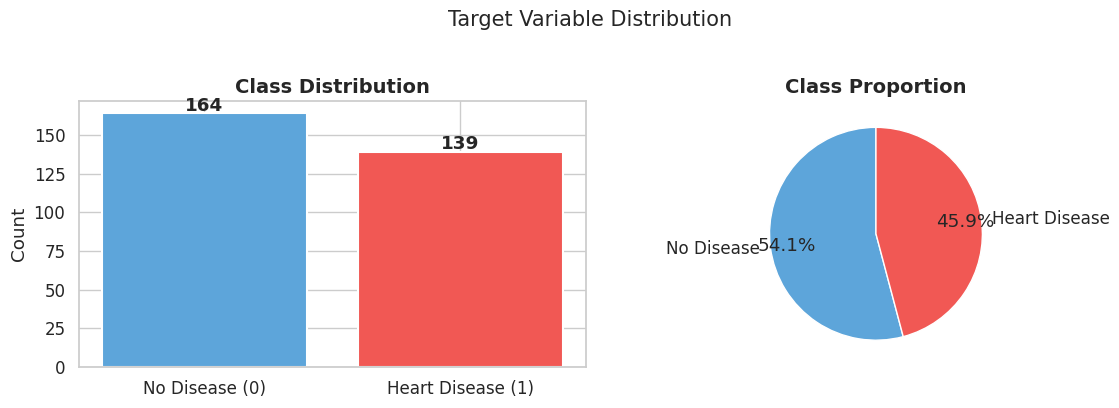


Class balance: 164 vs 139. No special resampling needed.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['target'].value_counts()
axes[0].bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
            color=['#5DA5DA', '#F15854'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['No Disease', 'Heart Disease'],
            colors=['#5DA5DA', '#F15854'], autopct='%1.1f%%',
            startangle=90, pctdistance=0.85)
axes[1].set_title('Class Proportion', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable Distribution', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nClass balance: {counts[0]} vs {counts[1]}. No special resampling needed.")

### 2.3 — Feature Distributions

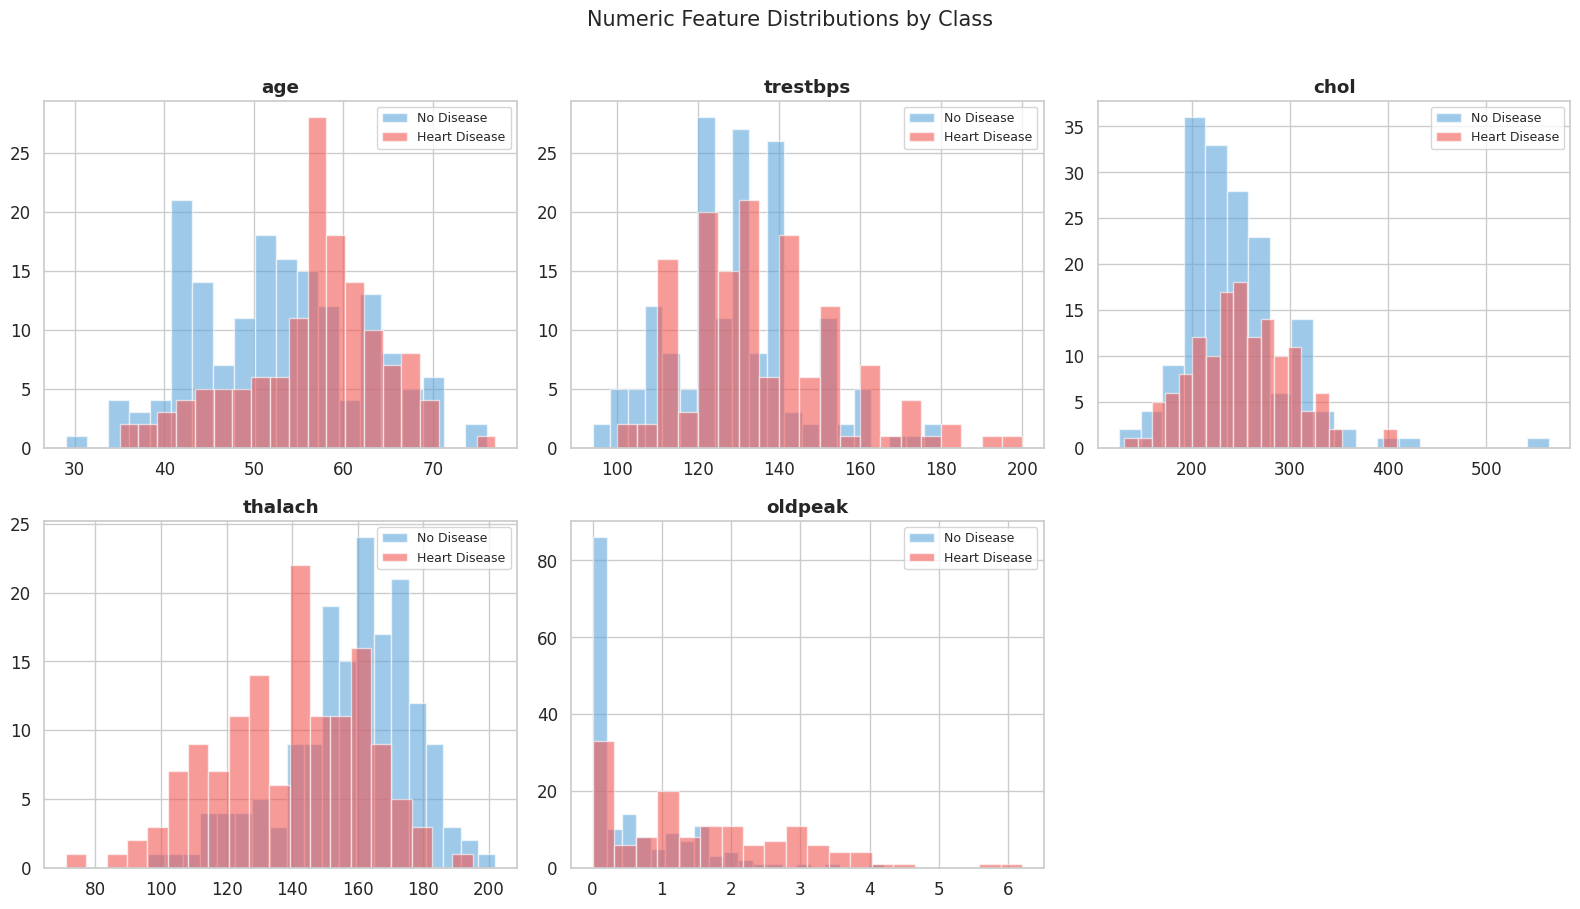

In [ ]:
# Separate features into numeric (continuous) and categorical
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    # Histogram split by target class
    axes[i].hist(df[df['target'] == 0][col].dropna(), bins=20,
                 alpha=0.6, label='No Disease', color='#5DA5DA')
    axes[i].hist(df[df['target'] == 1][col].dropna(), bins=20,
                 alpha=0.6, label='Heart Disease', color='#F15854')
    axes[i].set_title(col, fontweight='bold')
    axes[i].legend(fontsize=9)

axes[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Class', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

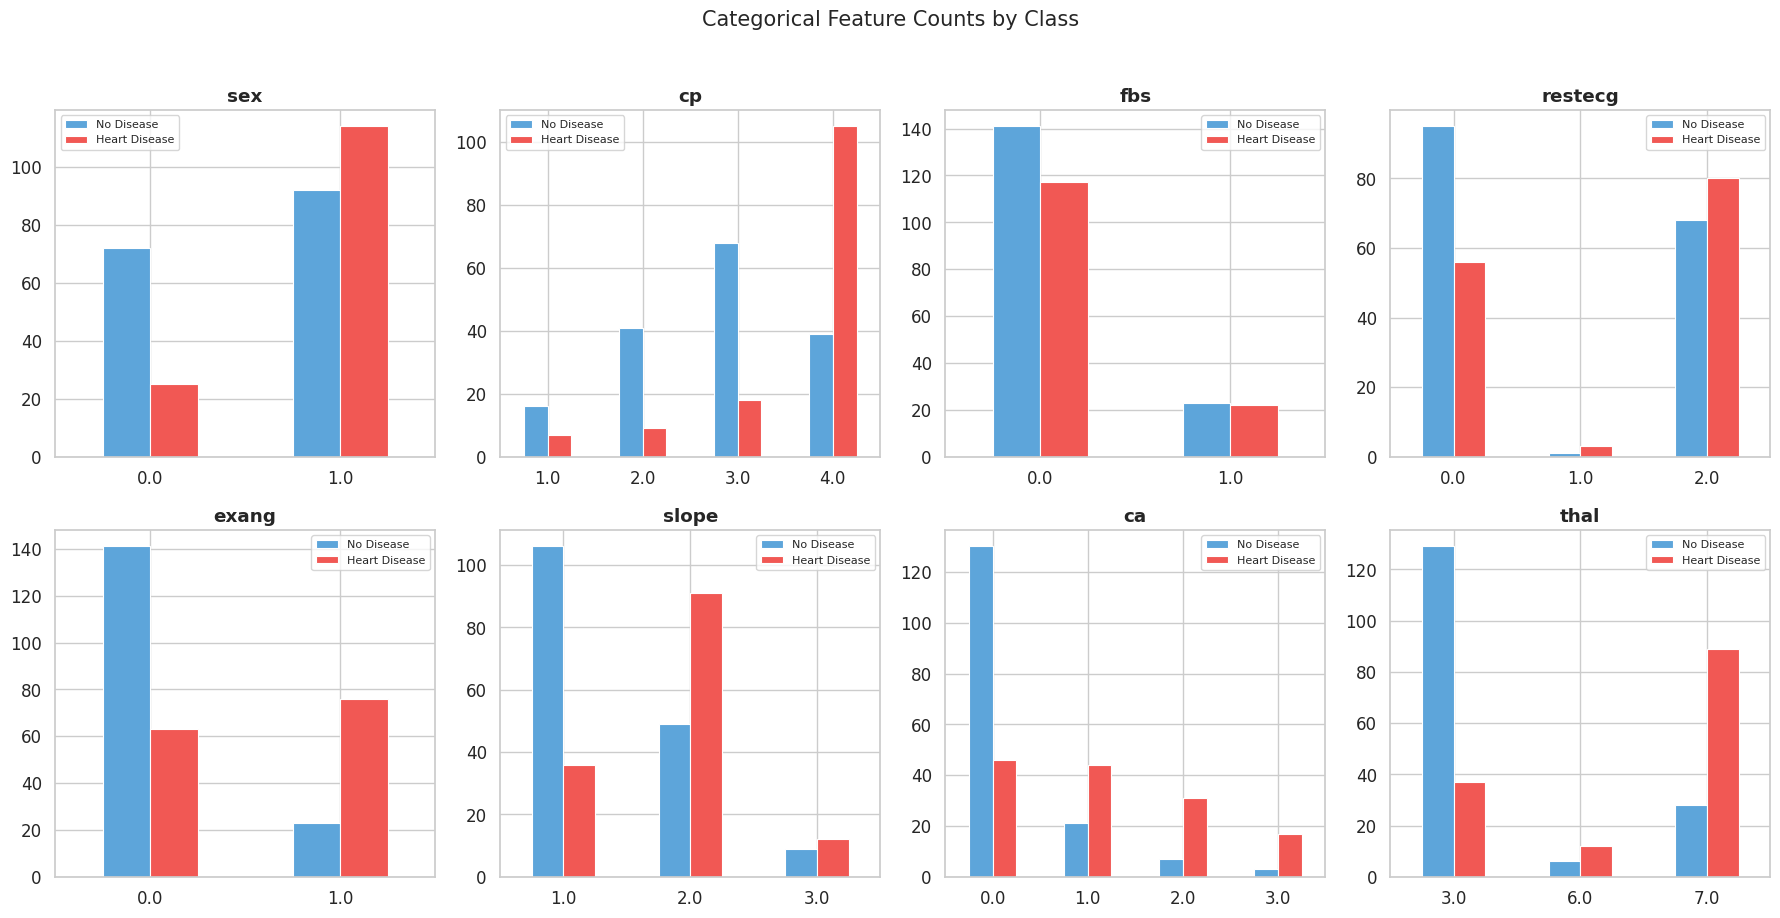

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=axes[i], color=['#5DA5DA', '#F15854'],
            edgecolor='white', linewidth=0.8)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['No Disease', 'Heart Disease'], fontsize=8)

plt.suptitle('Categorical Feature Counts by Class', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 2.4 — Correlation Heatmap

> A correlation heatmap shows how strongly pairs of features are linearly related. Values close to **+1** mean strong positive correlation, **-1** strong negative, and **0** no linear relationship.

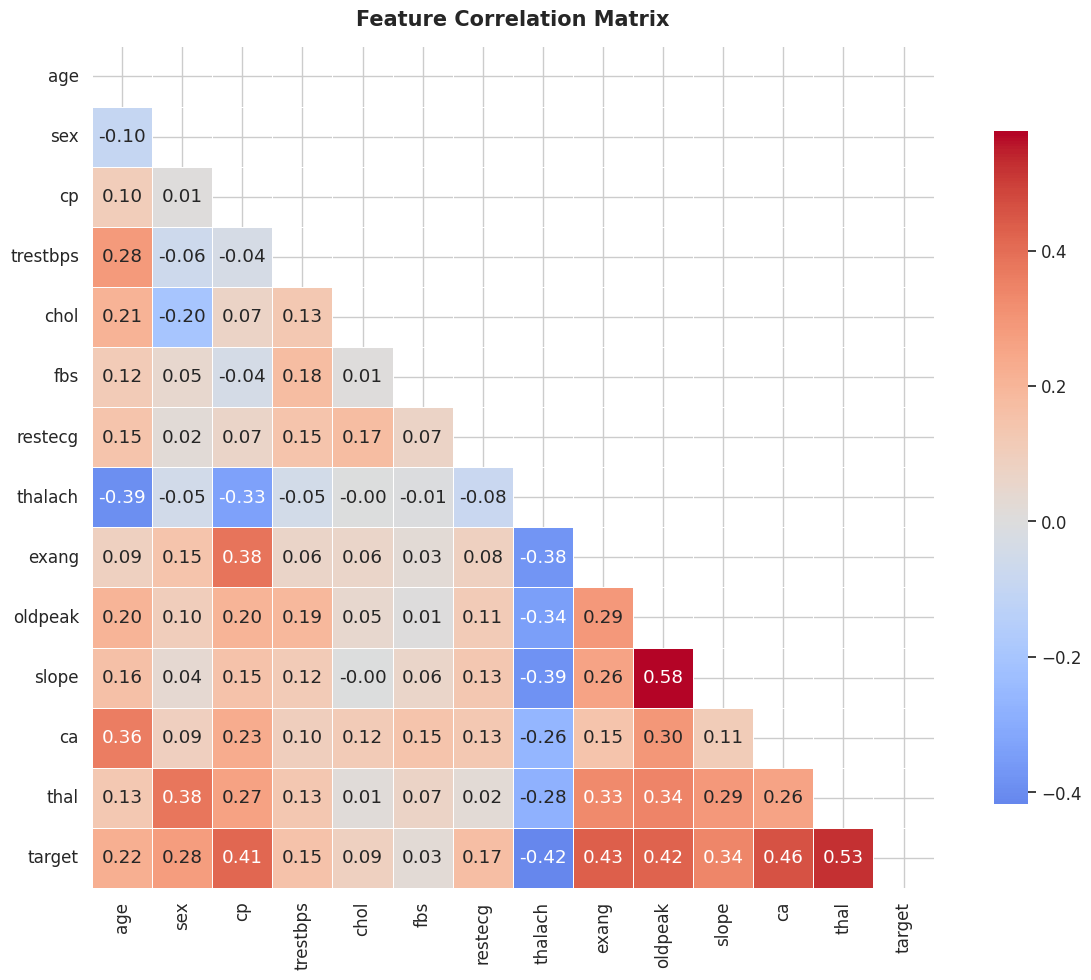


Top correlations with 'target':
thal       0.525689
ca         0.460442
exang      0.431894
oldpeak    0.424510
thalach    0.417167
cp         0.414446
slope      0.339213
sex        0.276816


In [ ]:
# Ensure numeric data only for correlation
df_numeric = df.apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(df_numeric.corr(), dtype=bool))  # Show only lower triangle
sns.heatmap(
    df_numeric.corr(),
    mask=mask,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5, linecolor='white',
    square=True, cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

# Highlight the top features most correlated with the target
print("\nTop correlations with 'target':")
print(df_numeric.corr()['target'].drop('target').abs().sort_values(ascending=False).head(8).to_string())

### 2.5 — Box Plots: Key Features vs Target

Box plots reveal medians, spread, and outliers — giving us intuition about which features will be useful predictors.

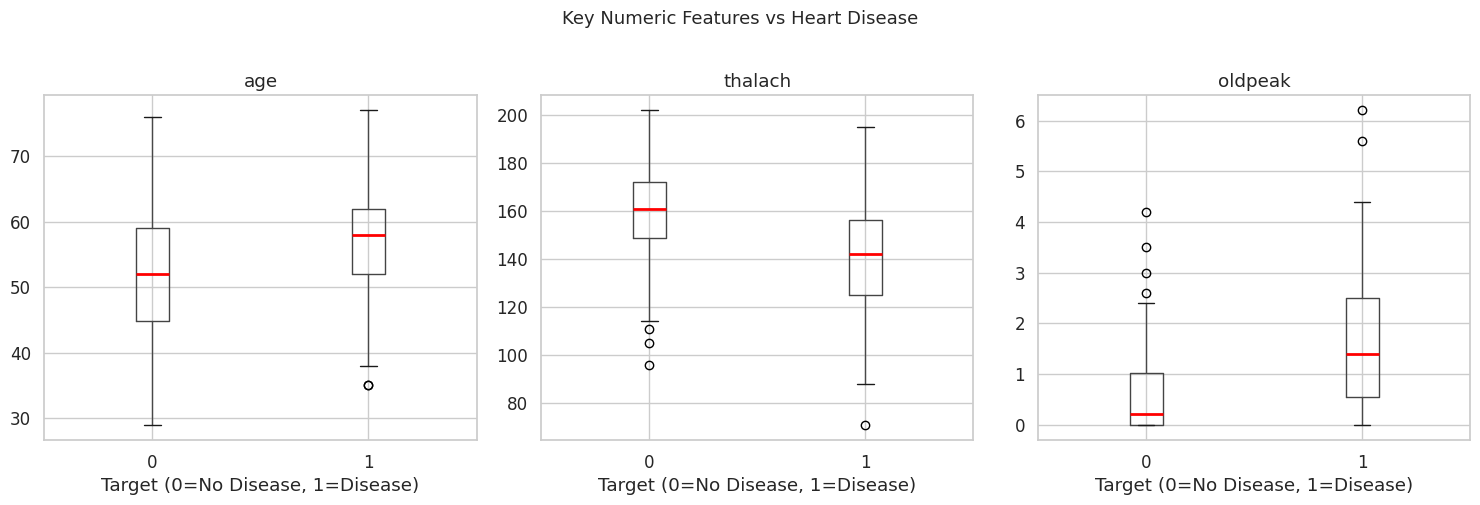


Key Observations:
  • Patients WITH heart disease tend to be older on average
  • Lower max heart rate (thalach) is associated with heart disease
  • Higher oldpeak (ST depression) correlates strongly with disease presence



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

key_features = ['age', 'thalach', 'oldpeak']
for ax, feat in zip(axes, key_features):
    df_numeric.boxplot(column=feat, by='target', ax=ax,
                       boxprops=dict(color='#444'),
                       medianprops=dict(color='red', linewidth=2))
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Target (0=No Disease, 1=Disease)')
    plt.sca(ax)
    plt.title(feat)

plt.suptitle('Key Numeric Features vs Heart Disease', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("""
Key Observations:
  • Patients WITH heart disease tend to be older on average
  • Lower max heart rate (thalach) is associated with heart disease
  • Higher oldpeak (ST depression) correlates strongly with disease presence
""")

---

## Step 3 — Data Preprocessing

> **Why preprocess?** Raw data is rarely model-ready. We must handle missing values, encode categorical variables, and scale numeric features.

### 3.1 — Handle Missing Values

In [ ]:
# Convert all columns to numeric (the '?' values become NaN during loading)
df = df.apply(pd.to_numeric, errors='coerce')

missing_count = df.isnull().sum()
print("Missing values before imputation:")
print(missing_count[missing_count > 0].to_string() or "None")

# Strategy: fill numeric missing values with the column median.
# Median is more robust than mean when outliers are present.
for col in df.columns:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Filled '{col}' missing values with median = {median_val}")

print(f"\nMissing values after imputation: {df.isnull().sum().sum()}")

Missing values before imputation:
ca      4
thal    2
  Filled 'ca' missing values with median = 0.0
  Filled 'thal' missing values with median = 3.0

Missing values after imputation: 0


### 3.2 — Split Features and Target

In [ ]:
X = df.drop('target', axis=1)  # All columns except the label
y = df['target']                # The label column

print(f"Features (X): {X.shape}  →  {X.columns.tolist()}")
print(f"Target   (y): {y.shape}  →  Classes: {sorted(y.unique())}")

Features (X): (303, 13)  →  ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target   (y): (303,)  →  Classes: [np.int64(0), np.int64(1)]


### 3.3 — Train / Test Split

> **Why split?** We train the model on one portion of data and evaluate it on a held-out portion it has never seen. This gives us an honest estimate of real-world performance.
>
> We use `stratify=y` to ensure both splits have the same class ratio — crucial for imbalanced datasets.

In [ ]:
# 80% for training, 20% for testing
# stratify=y ensures each split has the same class ratio as the full dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nTrain target distribution: {dict(y_train.value_counts().sort_index())}")
print(f"Test target distribution:  {dict(y_test.value_counts().sort_index())}")

Training set:  242 samples (80%)
Test set:      61 samples (20%)

Train target distribution: {0: np.int64(131), 1: np.int64(111)}
Test target distribution:  {0: np.int64(33), 1: np.int64(28)}


### 3.4 — Feature Scaling

> **Why scale?** Algorithms like Logistic Regression and SVM are sensitive to feature magnitudes. `age` ranges 0–100 while `chol` ranges 0–600 — without scaling, larger-magnitude features dominate. Tree-based methods (Decision Tree, Random Forest, XGBoost) are **not** affected by scaling.
>
> We fit the scaler **only on the training set** and apply it to both. Fitting on test data would cause **data leakage**.

In [ ]:
scaler = StandardScaler()

# Fit on training data ONLY — then transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # Use same mean/std from training!

print("Feature scaling complete.")
print(f"  Example — 'age' column before: mean={X_train['age'].mean():.1f}, std={X_train['age'].std():.1f}")
print(f"  Example — 'age' column after:  mean≈0, std≈1")
print("\nNote: Scaling is applied for Logistic Regression; tree models use the original X_train/X_test.")

Feature scaling complete.
  Example — 'age' column before: mean=54.5, std=9.0
  Example — 'age' column after:  mean≈0, std≈1

Note: Scaling is applied for Logistic Regression; tree models use the original X_train/X_test.


---

## Step 4 — Model Training & Evaluation

### Understanding the Evaluation Metrics

Before training, let's understand what each metric measures in a **clinical context**:

| Metric | Formula | In plain English | Clinical Importance |
|---|---|---|---|
| **Accuracy** | (TP+TN)/(Total) | % of all predictions correct | Misleading with imbalance |
| **Precision** | TP/(TP+FP) | Of predicted positives, how many are truly positive? | Reduces false alarms |
| **Recall** | TP/(TP+FN) | Of actual positives, how many did we catch? | **Critical** — misses = undiagnosed disease |
| **F1 Score** | 2×(P×R)/(P+R) | Harmonic mean of Precision & Recall | Balance between P and R |
| **ROC-AUC** | Area under ROC curve | Model's ability to rank positives higher than negatives | Overall discriminative power |

> **Clinical note:** In medicine, **Recall (Sensitivity)** is often more important than Precision. Missing a heart disease patient (False Negative) is usually worse than a false alarm (False Positive).

### Helper Functions

In [ ]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """Train a model, compute all metrics, return a result dictionary."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]  # Probability of class 1 (disease)

    results = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'ROC-AUC':   roc_auc_score(y_te, y_prob),
    }
    return results, model, y_pred, y_prob


def plot_confusion_matrix(ax, y_true, y_pred, title):
    """Plot a styled confusion matrix on a given axes."""
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'],
                linewidths=2, linecolor='white', cbar=False)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')


all_results = []   # Collect metric dicts for final comparison
all_models  = {}   # Store trained model objects
all_probs   = {}   # Store predicted probabilities for ROC curves

print("Helper functions defined. Ready to train models.")

Helper functions defined. Ready to train models.


---

### Model 1 — Logistic Regression

> **What it is:** Logistic Regression is the simplest linear classifier. It learns a boundary (a line/plane in feature space) that separates the two classes. Despite the name "regression", it predicts *probabilities* and is used for classification.
>
> **Strengths:** Fast, interpretable, works well when classes are linearly separable.  
> **Weaknesses:** Can't capture non-linear relationships without feature engineering.

In [ ]:
# C = regularisation strength (inverse); smaller C = more regularisation
# max_iter=1000 ensures convergence on this small dataset
lr_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)

# Logistic Regression needs SCALED features
lr_results, lr_model, lr_preds, lr_probs = evaluate_model(
    'Logistic Regression', lr_model, X_train_scaled, y_train, X_test_scaled, y_test
)
all_results.append(lr_results)
all_models['Logistic Regression'] = lr_model
all_probs['Logistic Regression'] = lr_probs

print("Logistic Regression Results:")
for k, v in lr_results.items():
    if k != 'Model':
        print(f"  {k:12s}: {v:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, lr_preds, target_names=['No Disease', 'Heart Disease']))

Logistic Regression Results:
  Accuracy    : 0.8689
  Precision   : 0.8125
  Recall      : 0.9286
  F1          : 0.8667
  ROC-AUC     : 0.9513

Detailed Classification Report:
               precision    recall  f1-score   support

   No Disease       0.93      0.82      0.87        33
Heart Disease       0.81      0.93      0.87        28

     accuracy                           0.87        61
    macro avg       0.87      0.87      0.87        61
 weighted avg       0.88      0.87      0.87        61



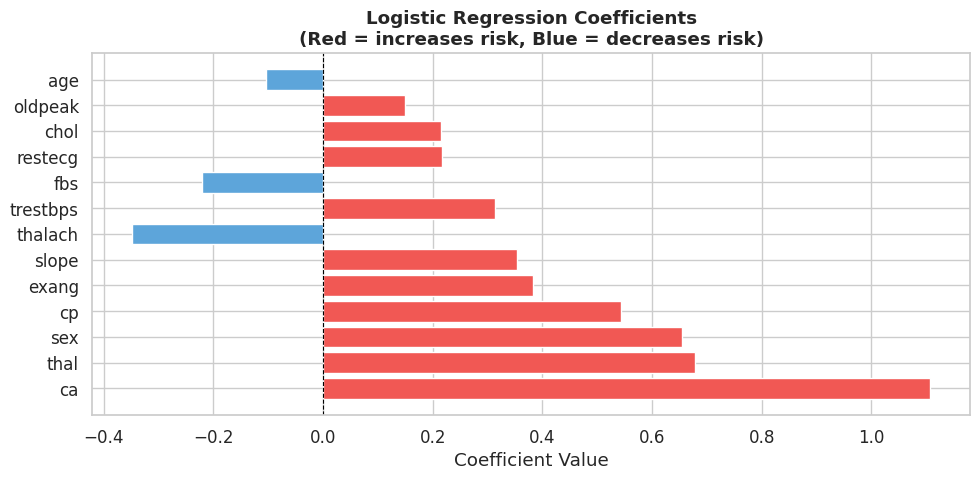

In [ ]:
# Feature importance for Logistic Regression = the learned coefficients.
# Larger absolute value = more influence on the prediction.
coef_df = pd.DataFrame({
    'Feature':     X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
colors = ['#F15854' if c > 0 else '#5DA5DA' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Logistic Regression Coefficients\n(Red = increases risk, Blue = decreases risk)',
          fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

---

### Model 2 — Decision Tree

> **What it is:** A Decision Tree splits data into subsets based on feature thresholds, creating a tree of if-then rules. It's fully interpretable — you can follow the path from root to leaf to understand any prediction.
>
> **Strengths:** Highly interpretable, handles non-linear relationships, no scaling needed.  
> **Weaknesses:** Prone to **overfitting** — a deep tree memorises the training data. We control depth with `max_depth`.

In [ ]:
# max_depth=5 prevents the tree from growing so deep it memorises training data
# min_samples_split=10 requires at least 10 samples to split a node
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    random_state=RANDOM_STATE
)

# Tree models don't need scaled features
dt_results, dt_model, dt_preds, dt_probs = evaluate_model(
    'Decision Tree', dt_model, X_train, y_train, X_test, y_test
)
all_results.append(dt_results)
all_models['Decision Tree'] = dt_model
all_probs['Decision Tree'] = dt_probs

print("Decision Tree Results:")
for k, v in dt_results.items():
    if k != 'Model':
        print(f"  {k:12s}: {v:.4f}")

# Print the actual decision rules (human-readable!)
print("\n── First 3 levels of Decision Rules ──────────────────")
print(export_text(dt_model, feature_names=list(X.columns), max_depth=3))

Decision Tree Results:
  Accuracy    : 0.7705
  Precision   : 0.7188
  Recall      : 0.8214
  F1          : 0.7667
  ROC-AUC     : 0.8528

── First 3 levels of Decision Rules ──────────────────
|--- thal <= 4.50
|   |--- ca <= 0.50
|   |   |--- age <= 57.50
|   |   |   |--- oldpeak <= 3.30
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- oldpeak >  3.30
|   |   |   |   |--- class: 1
|   |   |--- age >  57.50
|   |   |   |--- chol <= 271.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- chol >  271.00
|   |   |   |   |--- truncated branch of depth 2
|   |--- ca >  0.50
|   |   |--- cp <= 3.50
|   |   |   |--- chol <= 237.50
|   |   |   |   |--- class: 1
|   |   |   |--- chol >  237.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- cp >  3.50
|   |   |   |--- sex <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- sex >  0.50
|   |   |   |   |--- class: 1
|--- thal >  4.50
|   |--- cp <= 3.50
|   |   |--- ca <= 0.50
|   |   |   |--- t

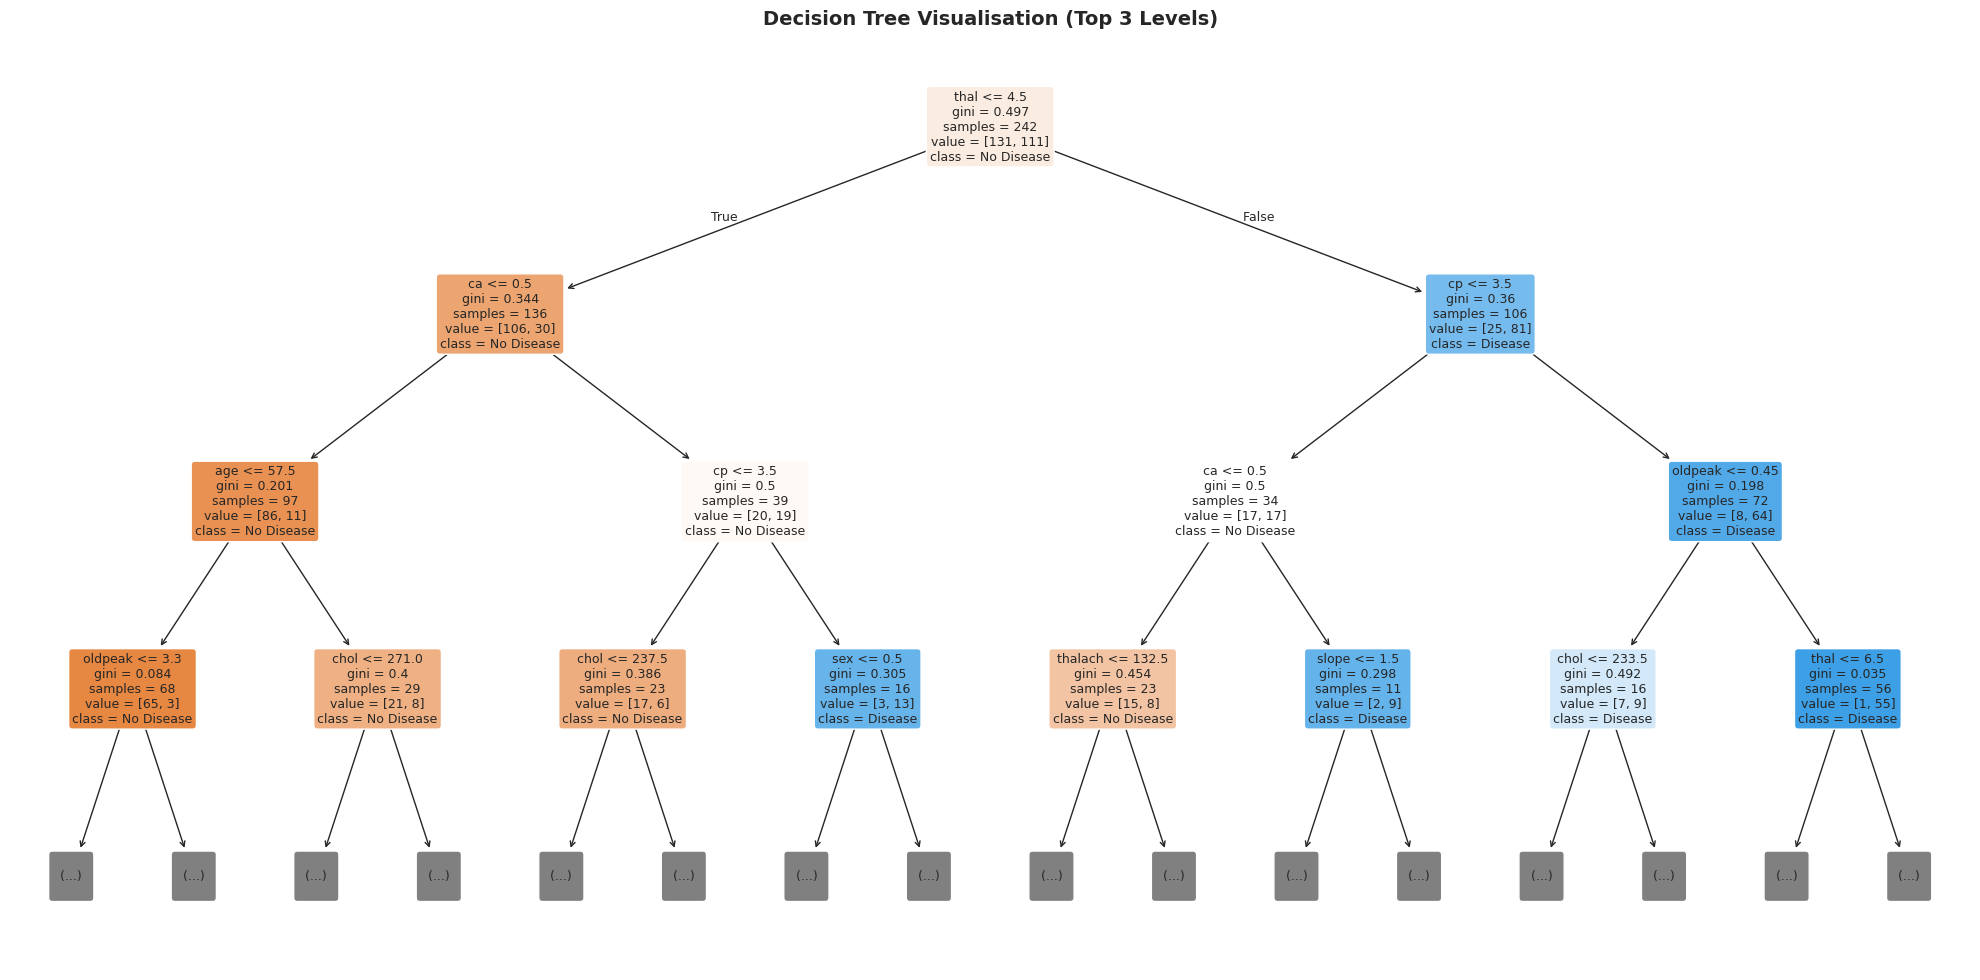

In [ ]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=['No Disease', 'Disease'],
    filled=True, rounded=True,
    max_depth=3,  # Show top 3 levels only for readability
    fontsize=9
)
plt.title('Decision Tree Visualisation (Top 3 Levels)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---

### Model 3 — Random Forest

> **What it is:** Random Forest is an **ensemble** of many Decision Trees. Each tree is trained on a random bootstrap sample of the data and a random subset of features. The final prediction is a majority vote across all trees.
>
> **Why it works:** Each tree makes different errors. By averaging many different trees, the errors cancel out — this is called **variance reduction**. Random Forests are often the best out-of-the-box classifiers.
>
> **Strengths:** Robust, handles non-linearity, less overfitting than single trees, provides feature importance.  
> **Weaknesses:** Less interpretable than a single tree, slower to predict than Logistic Regression.

In [ ]:
# n_estimators=200 — grow 200 trees (more = better, with diminishing returns)
# max_features='sqrt' — each tree sees sqrt(n_features) features at each split
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,         # Let trees grow fully — the ensemble handles overfitting
    max_features='sqrt',
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1               # Use all CPU cores
)

rf_results, rf_model, rf_preds, rf_probs = evaluate_model(
    'Random Forest', rf_model, X_train, y_train, X_test, y_test
)
all_results.append(rf_results)
all_models['Random Forest'] = rf_model
all_probs['Random Forest'] = rf_probs

print("Random Forest Results:")
for k, v in rf_results.items():
    if k != 'Model':
        print(f"  {k:12s}: {v:.4f}")

Random Forest Results:
  Accuracy    : 0.9016
  Precision   : 0.8667
  Recall      : 0.9286
  F1          : 0.8966
  ROC-AUC     : 0.9502


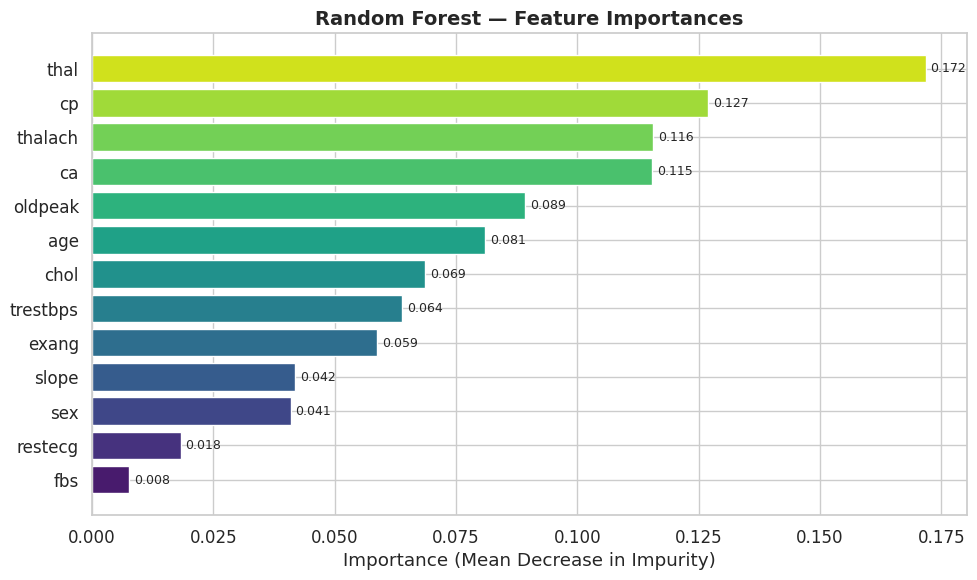


Top 3 most important features: ['thal', 'cp', 'thalach']


In [ ]:
# Random Forests provide 'feature_importances_' — a measure of how much
# each feature reduces impurity across all trees.
fi_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(fi_df['Feature'], fi_df['Importance'],
                color=sns.color_palette('viridis', len(fi_df)))
plt.title('Random Forest — Feature Importances', fontsize=14, fontweight='bold')
plt.xlabel('Importance (Mean Decrease in Impurity)')

# Add value labels
for bar, val in zip(bars, fi_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTop 3 most important features: {fi_df.tail(3)['Feature'].tolist()[::-1]}")

---

### Model 4A — XGBoost (Extreme Gradient Boosting)

> **What it is:** XGBoost is a **gradient boosting** algorithm. Unlike Random Forest (parallel trees), boosting builds trees **sequentially** — each new tree learns to correct the errors made by previous trees.
>
> **Key idea:** We start with a simple model, then keep adding small "correction" trees that focus on the hardest examples.
>
> **Why it's popular:** XGBoost won dozens of Kaggle competitions and is highly optimised for speed and memory. It includes built-in regularization (L1/L2) to prevent overfitting.
>
> **Strengths:** State-of-the-art performance, handles missing values natively, very fast.  
> **Weaknesses:** More hyperparameters to tune, harder to interpret.

In [ ]:
# n_estimators = number of boosting rounds
# learning_rate = how much each tree contributes (lower = more trees needed, but better generalisation)
# max_depth = depth of each individual tree (keep low to prevent overfitting)
# subsample = fraction of samples used per tree (adds randomness like Random Forest)
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,   # Fraction of features used per tree
    use_label_encoder=False,
    eval_metric='logloss',  # Suppress warning
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_results, xgb_model, xgb_preds, xgb_probs = evaluate_model(
    'XGBoost', xgb_model, X_train, y_train, X_test, y_test
)
all_results.append(xgb_results)
all_models['XGBoost'] = xgb_model
all_probs['XGBoost'] = xgb_probs

print("XGBoost Results:")
for k, v in xgb_results.items():
    if k != 'Model':
        print(f"  {k:12s}: {v:.4f}")

XGBoost Results:
  Accuracy    : 0.8852
  Precision   : 0.8182
  Recall      : 0.9643
  F1          : 0.8852
  ROC-AUC     : 0.9426


### Model 4B — LightGBM (Light Gradient Boosting Machine)

> **What it is:** LightGBM is Microsoft's gradient boosting framework — faster and often more accurate than XGBoost on large datasets. Key innovations:
> - **Leaf-wise tree growth** (vs level-wise in XGBoost): grows the leaf with the most loss reduction, creating more complex but accurate trees
> - **GOSS** (Gradient-based One-Side Sampling): samples more from high-error instances
> - **EFB** (Exclusive Feature Bundling): combines sparse features to reduce dimensions
>
> **Strengths:** Faster training, lower memory, often top performance on tabular data.  
> **Weaknesses:** Leaf-wise growth can overfit on small datasets — regularization is important.

In [ ]:
# num_leaves controls model complexity (LightGBM's main parameter, unlike max_depth)
# min_child_samples prevents overfitting by requiring minimum samples per leaf
lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,          # Max 2^max_depth - 1 is a common rule of thumb
    min_child_samples=10,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1              # Suppress training logs
)

lgbm_results, lgbm_model, lgbm_preds, lgbm_probs = evaluate_model(
    'LightGBM', lgbm_model, X_train, y_train, X_test, y_test
)
all_results.append(lgbm_results)
all_models['LightGBM'] = lgbm_model
all_probs['LightGBM'] = lgbm_probs

print("LightGBM Results:")
for k, v in lgbm_results.items():
    if k != 'Model':
        print(f"  {k:12s}: {v:.4f}")

LightGBM Results:
  Accuracy    : 0.8852
  Precision   : 0.8387
  Recall      : 0.9286
  F1          : 0.8814
  ROC-AUC     : 0.9459


---

## Step 5 — Model Comparison

### 5.1 — Metrics Summary Table

In [ ]:
results_df = pd.DataFrame(all_results).set_index('Model')

# Style the table — highlight the best value in each column
styled = (results_df.style
          .format('{:.4f}')
          .highlight_max(axis=0, color='#c6efce')   # Green = best per column
          .set_caption('Model Comparison — All Metrics (green = best per metric)')
          .set_table_styles([{'selector': 'caption',
                              'props': [('font-size', '14px'), ('font-weight', 'bold')]}]))
styled

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8689,0.8125,0.9286,0.8667,0.9513
Decision Tree,0.7705,0.7188,0.8214,0.7667,0.8528
Random Forest,0.9016,0.8667,0.9286,0.8966,0.9502
XGBoost,0.8852,0.8182,0.9643,0.8852,0.9426
LightGBM,0.8852,0.8387,0.9286,0.8814,0.9459


### 5.2 — Grouped Bar Chart

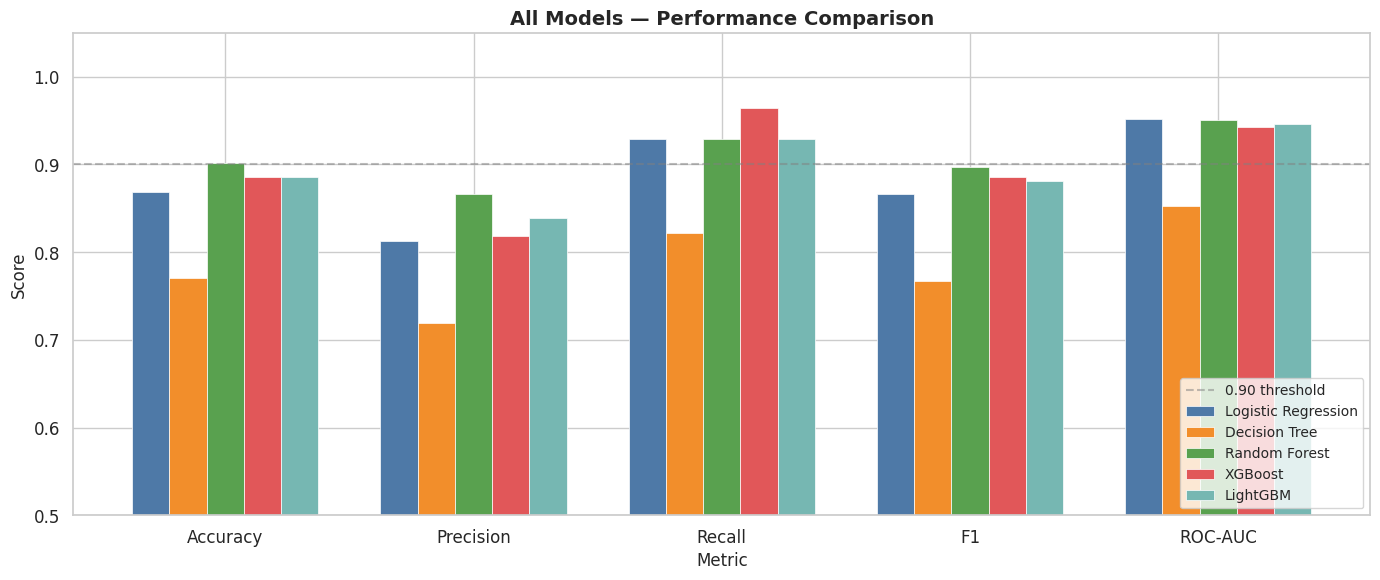

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
x = np.arange(len(metrics))
width = 0.15
colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#76B7B2']

fig, ax = plt.subplots(figsize=(14, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    offset = (i - len(results_df)/2 + 0.5) * width
    bars = ax.bar(x + offset, row[metrics], width, label=model_name,
                  color=colors[i], edgecolor='white', linewidth=0.5)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('All Models — Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='0.90 threshold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### 5.3 — Confusion Matrices for All Models

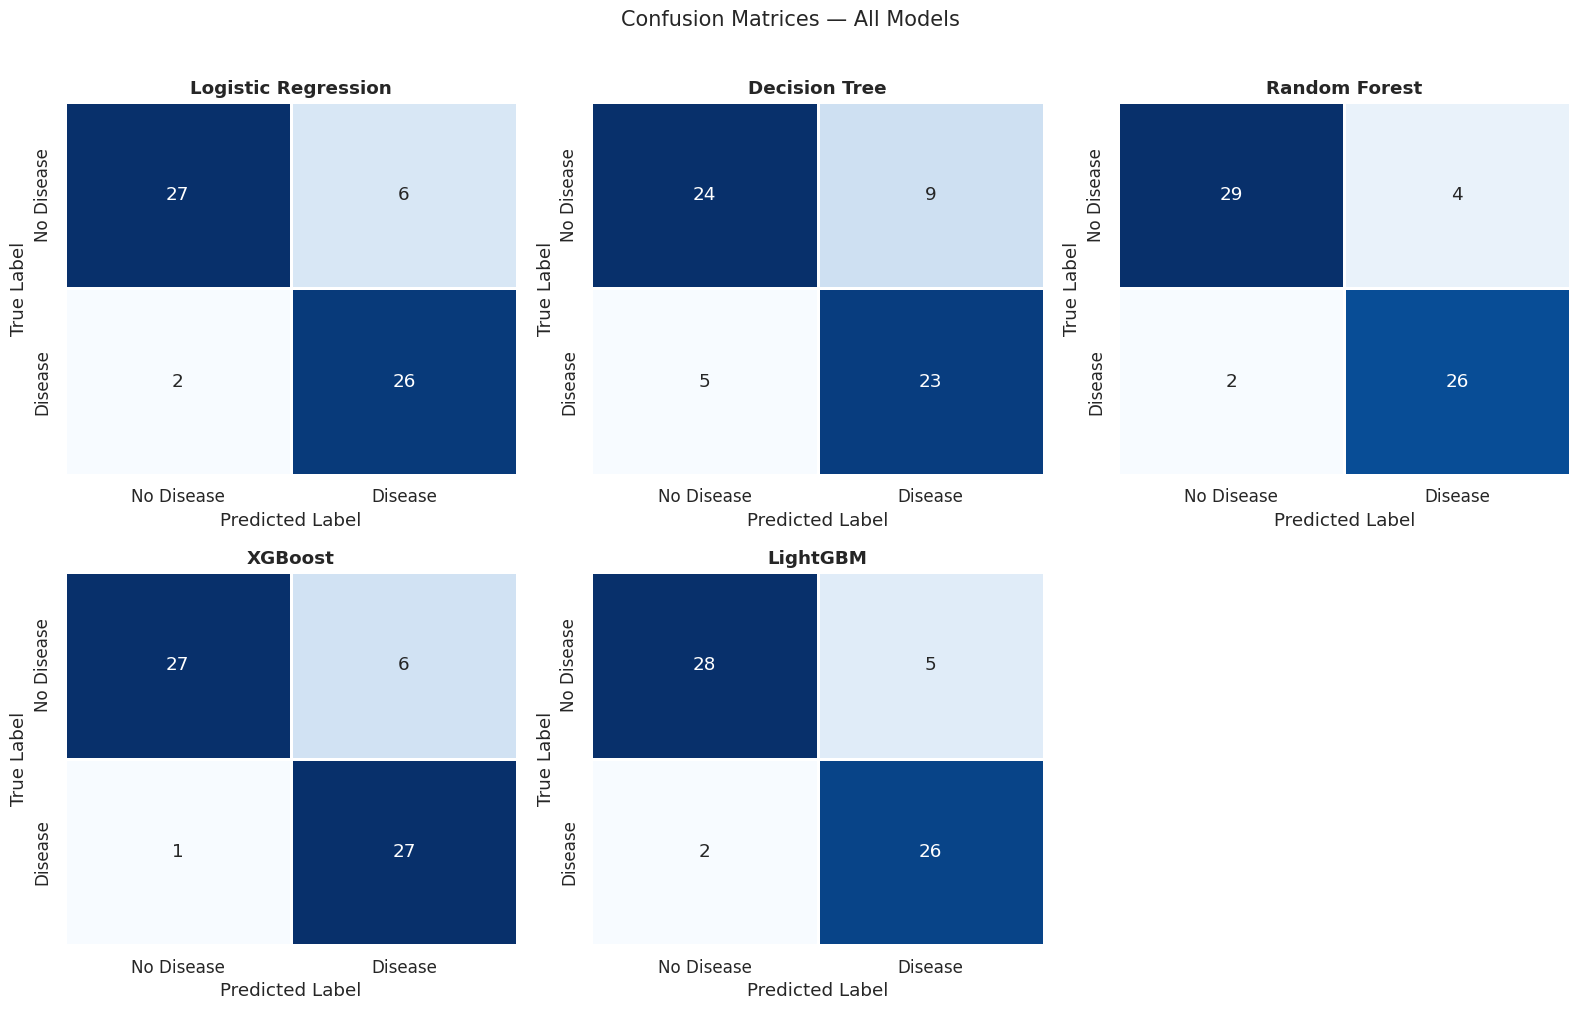


Reading the confusion matrix:
  Top-left (TN):  Correctly predicted No Disease
  Top-right (FP): Incorrectly predicted Disease (False Alarm)
  Bottom-left (FN): Missed Disease cases  ← most dangerous in clinical setting
  Bottom-right (TP): Correctly predicted Disease



In [ ]:
all_preds = {
    'Logistic Regression': lr_preds,
    'Decision Tree': dt_preds,
    'Random Forest': rf_preds,
    'XGBoost': xgb_preds,
    'LightGBM': lgbm_preds,
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, preds) in enumerate(all_preds.items()):
    plot_confusion_matrix(axes[i], y_test, preds, name)

axes[-1].axis('off')  # Hide last unused subplot
plt.suptitle('Confusion Matrices — All Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("""
Reading the confusion matrix:
  Top-left (TN):  Correctly predicted No Disease
  Top-right (FP): Incorrectly predicted Disease (False Alarm)
  Bottom-left (FN): Missed Disease cases  ← most dangerous in clinical setting
  Bottom-right (TP): Correctly predicted Disease
""")

### 5.4 — ROC Curves

> **ROC (Receiver Operating Characteristic) curve** plots True Positive Rate vs False Positive Rate at every possible classification threshold. The **AUC (Area Under the Curve)** summarises it in one number — closer to 1.0 = better. A random classifier gives AUC = 0.5 (the diagonal line).

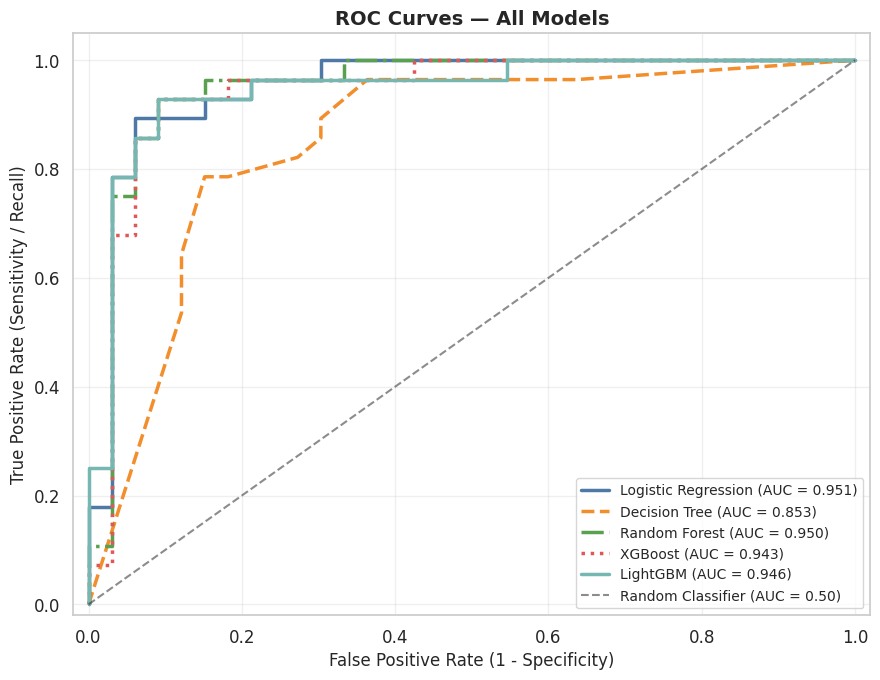

In [ ]:
plt.figure(figsize=(9, 7))

line_styles = ['-', '--', '-.', ':', '-']
roc_colors  = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#76B7B2']

for (name, probs), ls, color in zip(all_probs.items(), line_styles, roc_colors):
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2.5, linestyle=ls, color=color,
             label=f'{name} (AUC = {roc_auc:.3f})')

# Reference line — random classifier
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5, label='Random Classifier (AUC = 0.50)')

plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 — Cross-Validation (More Reliable Estimates)

> **Why cross-validate?** A single 80/20 split can be lucky or unlucky. With **Stratified K-Fold CV**, we repeat the evaluation k times on different folds, giving us a mean ± std estimate that's far more reliable — especially important on small datasets like this one (303 rows).

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree':        DecisionTreeClassifier(max_depth=5, min_samples_split=10, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':              XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                          eval_metric='logloss', verbosity=0, random_state=RANDOM_STATE),
    'LightGBM':             LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1, random_state=RANDOM_STATE),
}

cv_data = {
    'Logistic Regression': (X_train_scaled, y_train),
    'Decision Tree':        (X_train, y_train),
    'Random Forest':        (X_train, y_train),
    'XGBoost':              (X_train, y_train),
    'LightGBM':             (X_train, y_train),
}

print(f"{'Model':<22} {'CV F1 Mean':>12} {'± Std':>8}")
print('-' * 44)

cv_results = {}
for name, model in cv_models.items():
    X_cv, y_cv = cv_data[name]
    scores = cross_val_score(model, X_cv, y_cv, cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:<22} {scores.mean():.4f}       ± {scores.std():.4f}")

Model                    CV F1 Mean    ± Std
--------------------------------------------
Logistic Regression    0.8007       ± 0.0260
Decision Tree          0.6916       ± 0.0461
Random Forest          0.7867       ± 0.0267
XGBoost                0.7613       ± 0.0419
LightGBM               0.7649       ± 0.0273


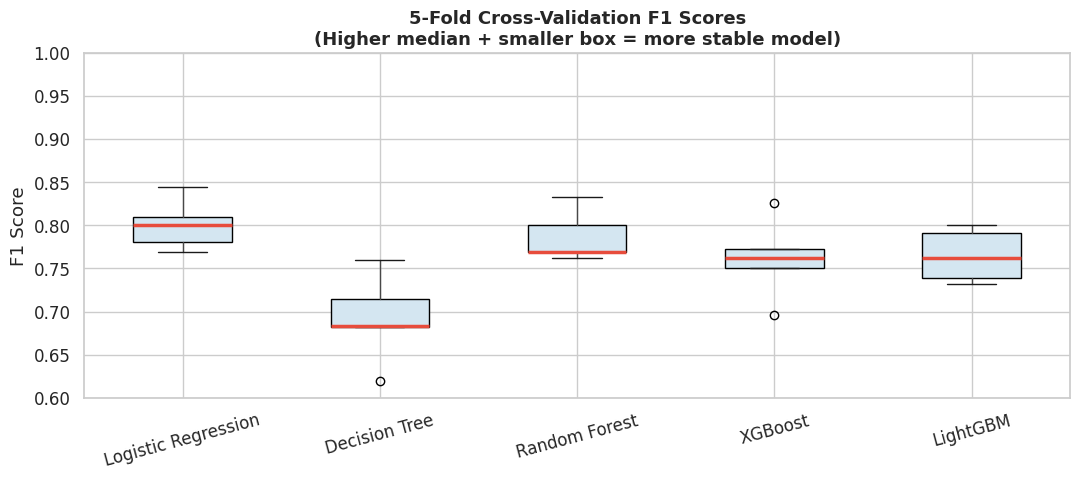

In [ ]:
# Visualise cross-validation distributions as box plots
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(11, 5))
cv_df.boxplot(vert=True, patch_artist=True,
              boxprops=dict(facecolor='#d4e6f1'),
              medianprops=dict(color='#e74c3c', linewidth=2.5))
plt.title('5-Fold Cross-Validation F1 Scores\n(Higher median + smaller box = more stable model)',
          fontsize=13, fontweight='bold')
plt.ylabel('F1 Score')
plt.xticks(rotation=15)
plt.ylim(0.6, 1.0)
plt.tight_layout()
plt.show()

---

## Step 6 — Feature Importance Comparison

Let's compare which features the three tree-based models consider most important.

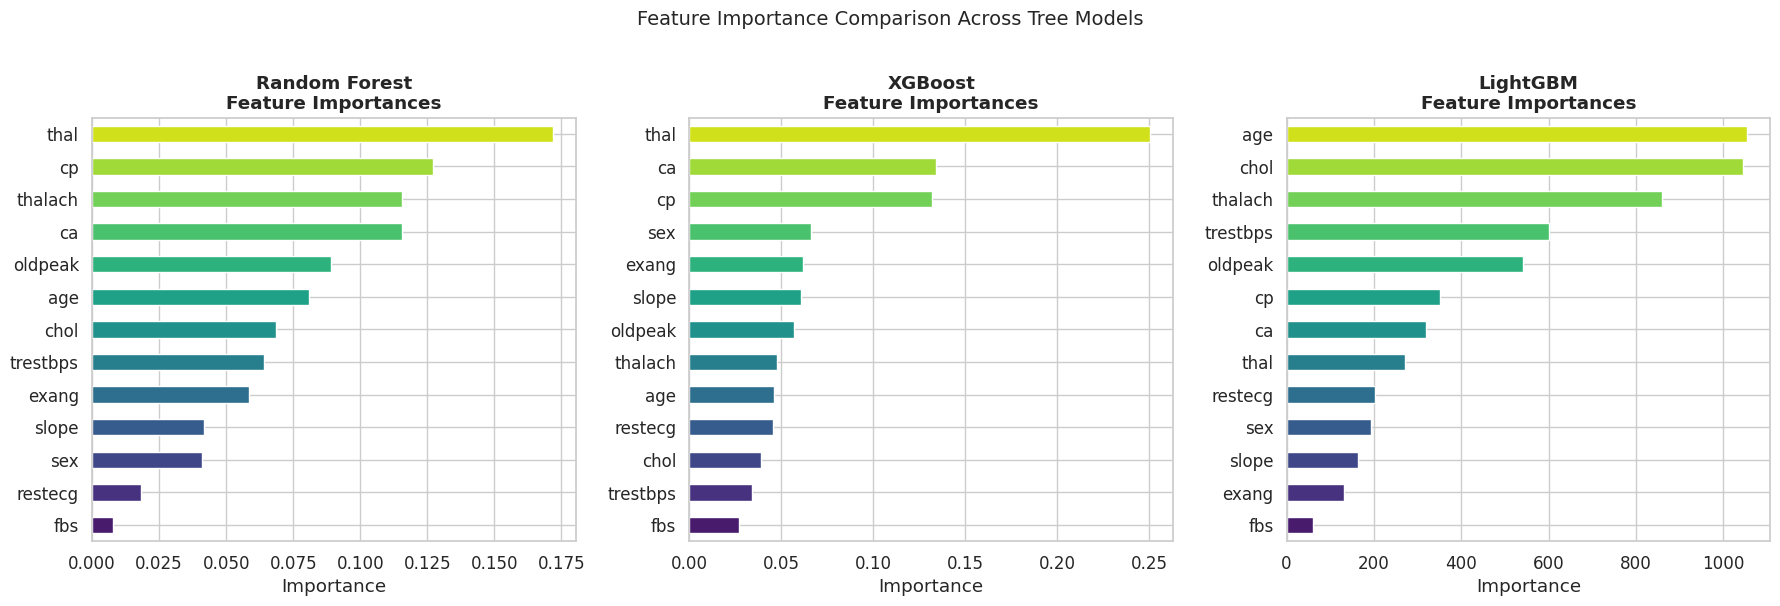


Clinical interpretation:
  • 'ca' (number of major vessels)  → powerful structural heart marker
  • 'thal' (thalassemia type)       → reflects blood flow abnormalities
  • 'cp' (chest pain type)          → classic heart disease symptom
  • 'oldpeak' (ST depression)       → stress-test cardiac indicator
  • 'thalach' (max heart rate)      → cardiovascular fitness proxy



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, [('Random Forest', rf_model),
                                      ('XGBoost', xgb_model),
                                      ('LightGBM', lgbm_model)]):
    importances = model.feature_importances_
    fi = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    fi.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(fi)))
    ax.set_title(f'{name}\nFeature Importances', fontweight='bold')
    ax.set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison Across Tree Models', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("""
Clinical interpretation:
  • 'ca' (number of major vessels)  → powerful structural heart marker
  • 'thal' (thalassemia type)       → reflects blood flow abnormalities
  • 'cp' (chest pain type)          → classic heart disease symptom
  • 'oldpeak' (ST depression)       → stress-test cardiac indicator
  • 'thalach' (max heart rate)      → cardiovascular fitness proxy
""")

---

## Step 7 — Best Model Selection & Final Interpretation

> **How to choose the best model?** It depends on your goal:
> - If **minimising false negatives** (missed diagnoses) → prioritise **Recall**
> - If **balanced overall performance** → prioritise **F1 Score**
> - If **ranking/threshold flexibility** → prioritise **ROC-AUC**
> - If **interpretability** is required → Logistic Regression or Decision Tree
> - If **raw accuracy** is the goal → Gradient Boosting models usually win

In [ ]:
print("═" * 60)
print("              MODEL SELECTION SUMMARY")
print("═" * 60)

# Best model by each metric
for metric in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']:
    best_model = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"  Best {metric:12s}: {best_model:<22} ({best_score:.4f})")

print("═" * 60)

# Overall recommendation based on F1 + AUC composite
composite = (results_df['F1'] + results_df['ROC-AUC']) / 2
best_overall = composite.idxmax()
print(f"\n  Recommended model (F1 + ROC-AUC composite): {best_overall}")
print("\n  In a clinical setting, also consider:")
best_recall = results_df['Recall'].idxmax()
print(f"    → Highest Recall (fewest missed diagnoses): {best_recall}")
print(f"    → Most interpretable for clinicians: Logistic Regression or Decision Tree")

════════════════════════════════════════════════════════════
              MODEL SELECTION SUMMARY
════════════════════════════════════════════════════════════
  Best Accuracy    : Random Forest          (0.9016)
  Best Precision   : Random Forest          (0.8667)
  Best Recall      : XGBoost                (0.9643)
  Best F1          : Random Forest          (0.8966)
  Best ROC-AUC     : Logistic Regression    (0.9513)
════════════════════════════════════════════════════════════

  Recommended model (F1 + ROC-AUC composite): Random Forest

  In a clinical setting, also consider:
    → Highest Recall (fewest missed diagnoses): XGBoost
    → Most interpretable for clinicians: Logistic Regression or Decision Tree


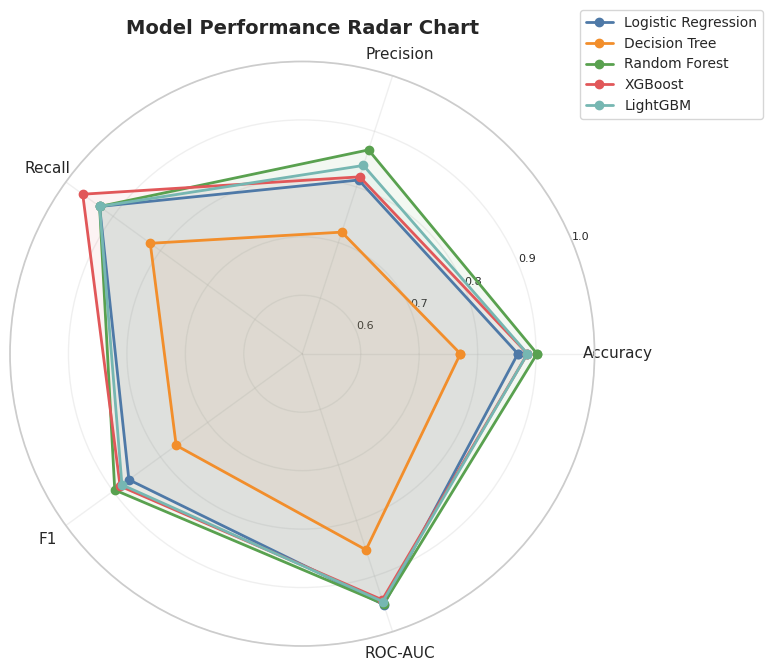

In [ ]:
# Final radar/spider chart — visual multi-metric comparison
from matplotlib.patches import FancyArrowPatch

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
N = len(metrics_radar)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # Close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = ['#4E79A7', '#F28E2B', '#59A14F', '#E15759', '#76B7B2']

for (model_name, row), color in zip(results_df.iterrows(), radar_colors):
    values = row[metrics_radar].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, label=model_name)
    ax.fill(angles, values, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_radar, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_yticklabels(['0.6', '0.7', '0.8', '0.9', '1.0'], fontsize=8)
ax.grid(True, alpha=0.3)

plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
plt.title('Model Performance Radar Chart', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---

## Step 8 — Making Predictions on New Patients

Let's simulate using our best model to predict risk for a new patient.

In [ ]:
# Select best model by F1+AUC composite score
composite = (results_df['F1'] + results_df['ROC-AUC']) / 2
best_model_name = composite.idxmax()
best_model = all_models[best_model_name]

print(f"Using: {best_model_name}")

# Each value corresponds to: age, sex, cp, trestbps, chol, fbs, restecg,
#                            thalach, exang, oldpeak, slope, ca, thal

new_patients = pd.DataFrame([
    # Patient A: 63yo male, chest pain type 3, high cholesterol, low max HR
    [63, 1, 3, 145, 233, 1, 0, 150, 0, 2.3, 0, 0, 1],
    # Patient B: 41yo female, no chest pain, normal values, high max HR
    [41, 0, 0, 130, 204, 0, 0, 172, 0, 1.4, 2, 0, 2],
], columns=X.columns)

predictions = best_model.predict(new_patients)
probabilities = best_model.predict_proba(new_patients)[:, 1]

print("\n" + "-" * 55)
print(f"  {'Patient':<10} {'Prediction':<22} {'Risk Probability'}")
print("-" * 55)
for i, (pred, prob) in enumerate(zip(predictions, probabilities), 1):
    label = 'HEART DISEASE' if pred == 1 else 'NO DISEASE'
    risk_bar = '#' * int(prob * 20) + '.' * (20 - int(prob * 20))
    print(f"  Patient {i:<3}  {label:<22} {prob:.1%}  [{risk_bar}]")
print("-" * 55)

print("\nNote: This is a demonstration only.")
print("Real clinical decisions require a qualified physician.")

Using: Random Forest

-------------------------------------------------------
  Patient    Prediction             Risk Probability
-------------------------------------------------------
  Patient 1    NO DISEASE             27.8%  [#####...............]
  Patient 2    NO DISEASE             3.9%  [....................]
-------------------------------------------------------

Note: This is a demonstration only.
Real clinical decisions require a qualified physician.


---

## Step 9 — Key Concepts Summary

### What We Learned

| Concept | Key Takeaway |
|---|---|
| **EDA** | Always explore your data before modelling. Visualise distributions, check balance, find correlations. |
| **Data leakage** | Fit scalers/imputers on training data only. Applying fit to test data "leaks" information and inflates scores. |
| **Stratified splits** | Use `stratify=y` in train/test split to preserve class ratios — critical for imbalanced data. |
| **Logistic Regression** | Best interpretability, needs scaled features, linear decision boundary. |
| **Decision Trees** | Fully interpretable rules, prone to overfitting — control with `max_depth`. |
| **Random Forest** | Robust ensemble, high accuracy, great feature importance — workhorse algorithm. |
| **XGBoost/LightGBM** | State-of-the-art tabular ML, sequential boosting, regularisation built-in. |
| **Recall vs Precision** | In medicine, catching all true cases (Recall) often matters more than minimising false alarms (Precision). |
| **Cross-validation** | More reliable than a single split — always report CV scores on small datasets. |
| **ROC-AUC** | Threshold-independent performance measure. Use it when ranking/probability calibration matters. |



In [ ]:
print("Models trained:   Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM")
print("Metrics covered:  Accuracy, Precision, Recall, F1, ROC-AUC")
print("Techniques used:  EDA, feature scaling, stratified splits, cross-validation")
print()

print("Final Model Leaderboard (sorted by ROC-AUC):")
print(results_df.sort_values('ROC-AUC', ascending=False).to_string())

Models trained:   Logistic Regression, Decision Tree, Random Forest, XGBoost, LightGBM
Metrics covered:  Accuracy, Precision, Recall, F1, ROC-AUC
Techniques used:  EDA, feature scaling, stratified splits, cross-validation

Final Model Leaderboard (sorted by ROC-AUC):
                     Accuracy  Precision    Recall        F1   ROC-AUC
Model                                                                 
Logistic Regression  0.868852   0.812500  0.928571  0.866667  0.951299
Random Forest        0.901639   0.866667  0.928571  0.896552  0.950216
LightGBM             0.885246   0.838710  0.928571  0.881356  0.945887
XGBoost              0.885246   0.818182  0.964286  0.885246  0.942641
Decision Tree        0.770492   0.718750  0.821429  0.766667  0.852814
